<a href="https://colab.research.google.com/github/Leo05-u/EMSC2010_A3-Project-Notebook-Repository/blob/main/EMSC2010_A3_Project_Notebook_%26_Repository_u7447903.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**A3:** Project Notebook & Repository

**Student:** Leo Moore (u7447903)
<br><br>

**Problem framing and scope**

– Clear, well-defined question; scope is appropriate and well justified

– Question is present but vague, overly broad, or weakly motivated

– Question unclear or not meaningfully addressed

<br>

**Methodological reasoning**

– Methods are appropriate, clearly explained, and explicitly linked to the research question

– Methods are appropriate but weakly justified or poorly explained

– Methods inappropriate, unexplained, or misapplied
<br><br>

**Use and understanding of data**

– Data are loaded, cleaned, and handled sensibly; assumptions and choices are clearly acknowledged

– Data are used, but there are issues with cleaning, assumptions, or understanding

– Data are mishandled or used without evident understanding
<br><br>

**Interpretation and critical thinking**

– Results are interpreted thoughtfully, with discussion of limitations and uncertainty

– Interpretation is present but superficial or incomplete

– Results are reported without interpretation or critical reflection
<br><br>

**Reproducibility and archiving**

– Notebook runs as submitted; repository is well organised; required data files are accessible; instructions are clear

– Minor reproducibility or organisation issues (e.g. unclear paths or missing notes)

– Notebook is not reproducible or repository is poorly organised


**Aim:**

**Dataset selection & cleaning**

Data was found from https://anu365-my.sharepoint.com/:x:/g/personal/u7447903_anu_edu_au/IQByZJS4Cp7JS5tvc3dwtmM7AbzltfYk_iXXTVLNupq2W1c?e=Fuwv62

Clean data is https://anu365-my.sharepoint.com/:x:/g/personal/u7447903_anu_edu_au/IQBHRjtq0kTeQIHrPhKs4CuhAe9TkeEBmuRkty7g4z5emvY?e=5LvksX

**Introduction:**

In [ ]:
#IMPORTING THE LIBRARIES
import pandas as pd #for data importing
import numpy as np #for numerical operations
import matplotlib.pyplot as plt #for plotting

#Note to self: delete any imports that don't get utilised

In [ ]:
# Enable custom widget support in Google Colab's output cell
from google.colab import output
output.enable_custom_widget_manager()

# Plotly: interactive, browser-based charting library
import plotly.graph_objects as go

# ipywidgets: interactive UI widgets for Jupyter/Colab notebooks (sliders, dropdowns, etc.)
import ipywidgets as widgets

# IPython display utilities:
# - display: renders rich output (widgets, HTML, images) in notebook cells
# - clear_output: clears the current cell's output (useful for dynamic updates)
from IPython.display import display, clear_output

In [ ]:
# Load the cleaned coral cover dataset from the Excel file

spreadsheet_name = 'Monthly_B&DRates_ByYear.xlsx'
worksheet_name = 'Sheet1'

df = pd.read_excel(spreadsheet_name, sheet_name=worksheet_name)

In [ ]:
#showing the dataframe
df.head()

,Year,Month,Births,Deaths
0,2015,January,6001,4698
1,2015,February,7441,3926
2,2015,March,8612,3718
3,2015,April,8079,3846
4,2015,May,12551,4757


In [ ]:
#Averaging the yearly birth and death rates

average_yearly_births = df.groupby('Year')['Births'].mean()
display(average_yearly_births)

average_yearly_deaths = df.groupby('Year')['Deaths'].mean()
display(average_yearly_deaths)

,Births
Year,
2015,8242.666667
2016,7901.166667
2017,7735.416667
2018,9028.583333
2019,8127.250000
2020,7852.416667
2021,8330.833333
2022,8028.333333
2023,7551.000000


,Deaths
Year,
2015,4420.500000
2016,4437.083333
2017,4348.583333
2018,4434.916667
2019,4637.000000
2020,4338.000000
2021,4661.916667
2022,5191.583333
2023,4905.833333


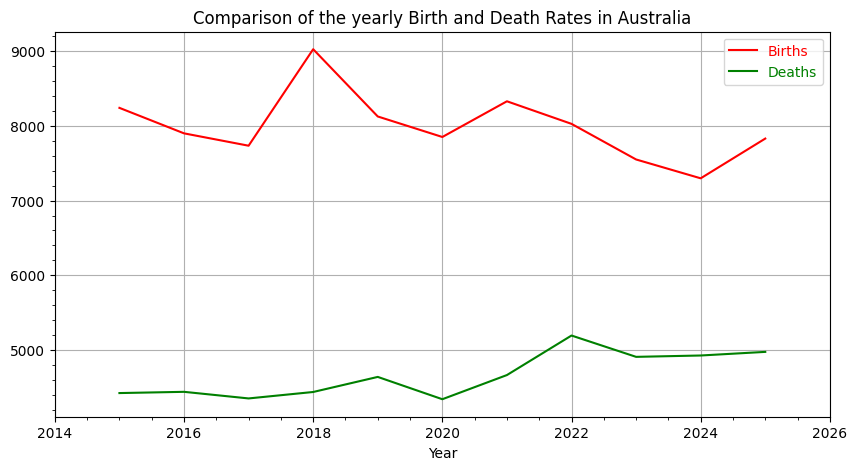

In [ ]:
#Generating the rough plot for the yearly birth and death rates

fig, ax = plt.subplots(figsize=(10, 5)) #size of plot
ax.plot(average_yearly_births.index, average_yearly_births,'r') #Births per year
ax.plot(average_yearly_deaths.index, average_yearly_deaths,'g') #Deaths per year
ax.set_xlabel('Year') #text for the x-axis label
ax.set_title('Comparison of the yearly Birth and Death Rates in Australia') #text for the title
legend = ax.legend(['Births','Deaths'], labelcolor='linecolor') #text for the legend
ax.grid() #show the gridlines
ax.set_xlim([2014,2026]) #interval for the x-axis
ax.minorticks_on() #show the minor ticks

Bootstrapping Data

In [ ]:
BS_Births = np.random.choice(df['Births'], size=len(df['Births']), replace=True) #find the mean of the X array
print(np.mean(BS_Births))

BS_Deaths = np.random.choice(df['Deaths'], size=len(df['Deaths']), replace=True) #find the mean of the X array
print(np.mean(BS_Deaths))

7938.575757575758
4691.674242424242


In [ ]:
BS2_Births = np.random.choice(df['Births'], size=(len(df['Births']), 1000), replace=True) #Generate 1000 columns of Bootstraps
print(np.shape(BS2_Births))

BS2_Deaths = np.random.choice(df['Deaths'], size=(len(df['Deaths']), 1000), replace=True) #Generate 1000 columns of Bootstraps
print(np.shape(BS2_Deaths))

(132, 1000)
(132, 1000)


(1000,)
(1000,)


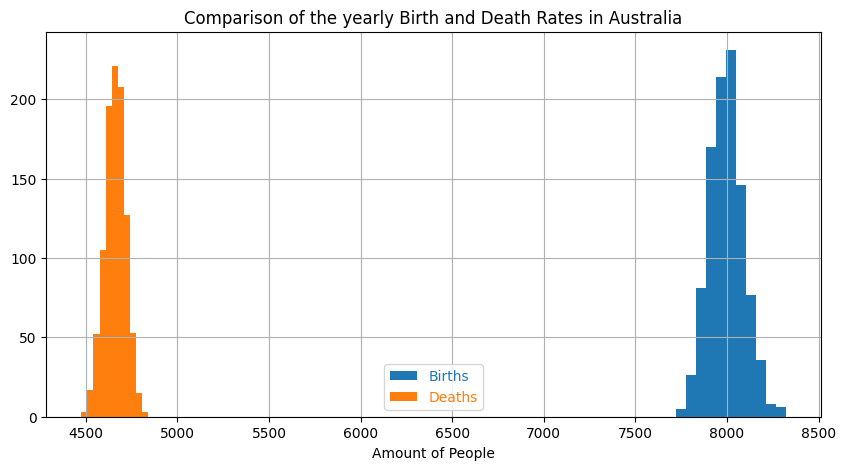

In [ ]:
bar_B = np.mean(BS2_Births, axis=0) #average of each column of the bootstrap for births
print(np.shape(bar_B))

bar_D = np.mean(BS2_Deaths, axis=0) #average of each column of the bootstrap for deaths
print(np.shape(bar_D))

# Creating a histogram for the bootstrap
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(bar_B, bins=11, label='Births') #11 used because its the amount of years of the dataset
ax.hist(bar_D, bins=11, label='Deaths') #11 used because its the amount of years of the dataset

ax.set_xlabel('Amount of People') #text for the x-axis label
ax.set_title('Comparison of the yearly Birth and Death Rates in Australia') #text for the title
ax.legend(labelcolor='linecolor') #text for the legend
ax.grid() #show the gridlines
plt.show()

In [ ]:
#Finding the confidence interval for the birth and death rates

CI_B = np.percentile(bar_B, [2.5, 97.5]) #95% confidence interval of births
print(CI_B)

CI_D = np.percentile(bar_D, [2.5, 97.5]) #95% confidence interval of deaths
print(CI_D)

[7824.22746212 8183.41685606]
[4546.21477273 4767.73598485]


Polynomial regression

In [ ]:
!pip install bambi # Install bambi
import bambi as bmb # Use bambi, aliased as bmb
import arviz as az #for analysis of Bayesian models

data_B = pd.DataFrame({"x": df['Year'], "y": df['Births']}) #put the data into a dataframe with variable names "x" and "y".
model_B = bmb.Model("y ~ x", data_B) #setup the first-order polynomial model
idata_B = model_B.fit(draws=2000, tune=2000, chains=8) #sample the posteriors

data_D = pd.DataFrame({"a": df['Year'], "b": df['Deaths']}) #put the data into a dataframe with variable names "a" and "b".
model_D = bmb.Model("b ~ a", data_D) #setup the first-order polynomial model
idata_D = model_D.fit(draws=2000, tune=2000, chains=8) #sample the posteriors

Output()

Output()

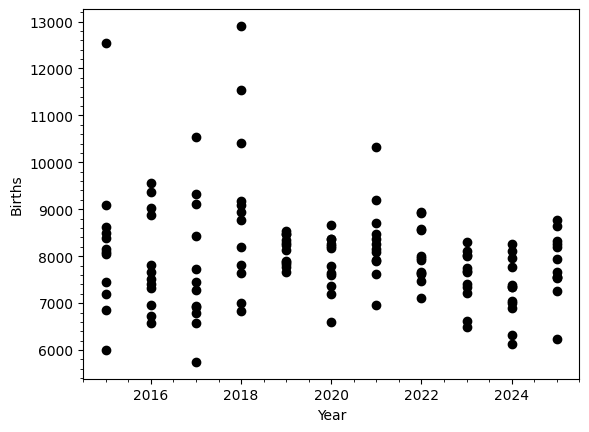

In [ ]:
plt.plot(df['Year'], df['Births'],'ok')
plt.xlabel('Year')
plt.ylabel('Births')
plt.minorticks_on()

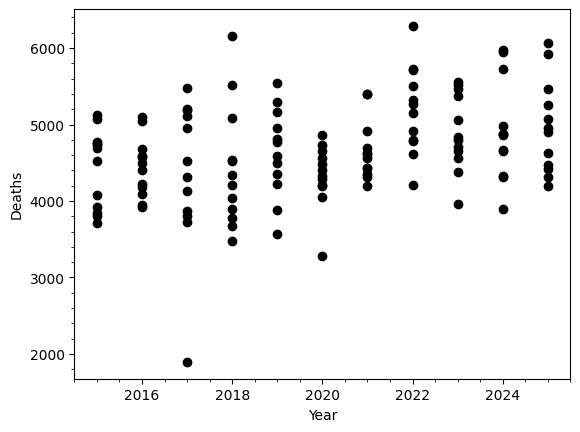

In [ ]:
plt.plot(df['Year'], df['Deaths'],'ok')
plt.xlabel('Year')
plt.ylabel('Deaths')
plt.minorticks_on()

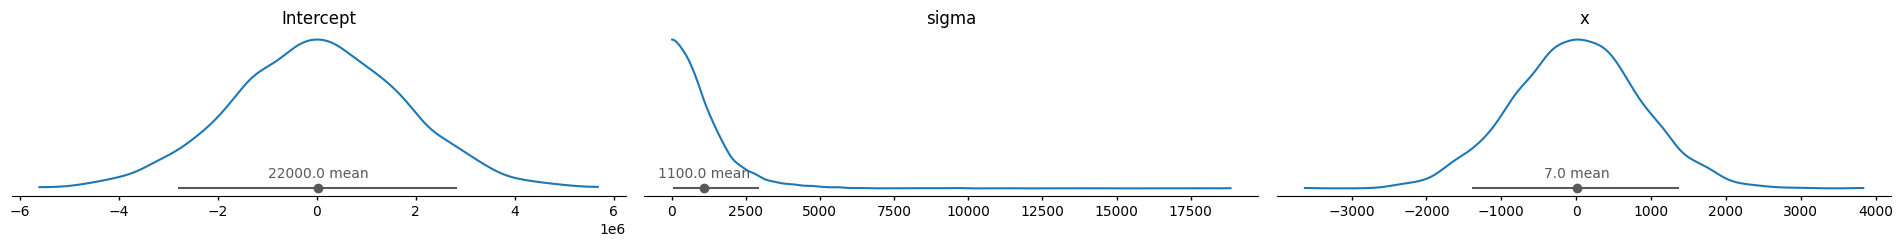

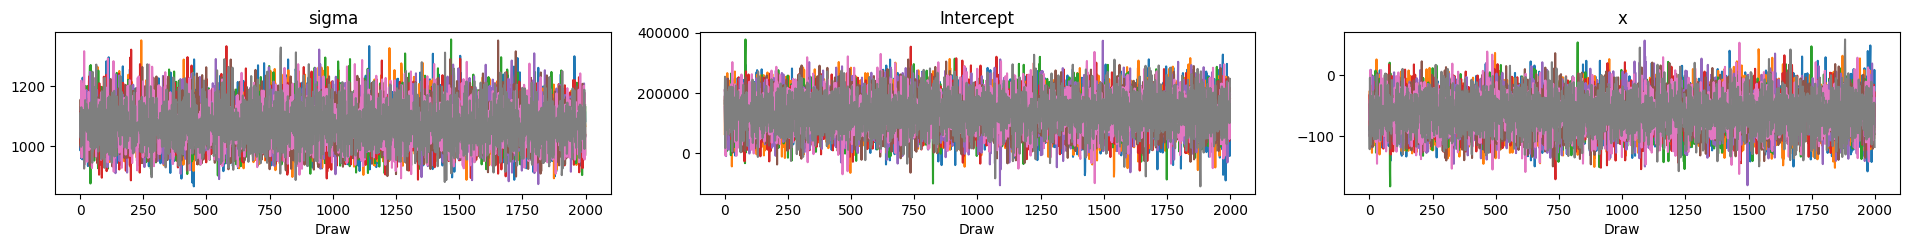

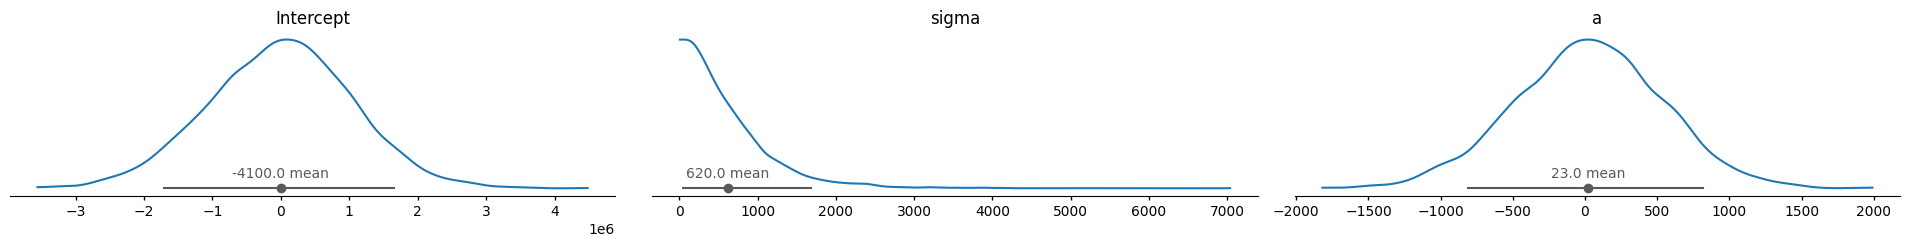

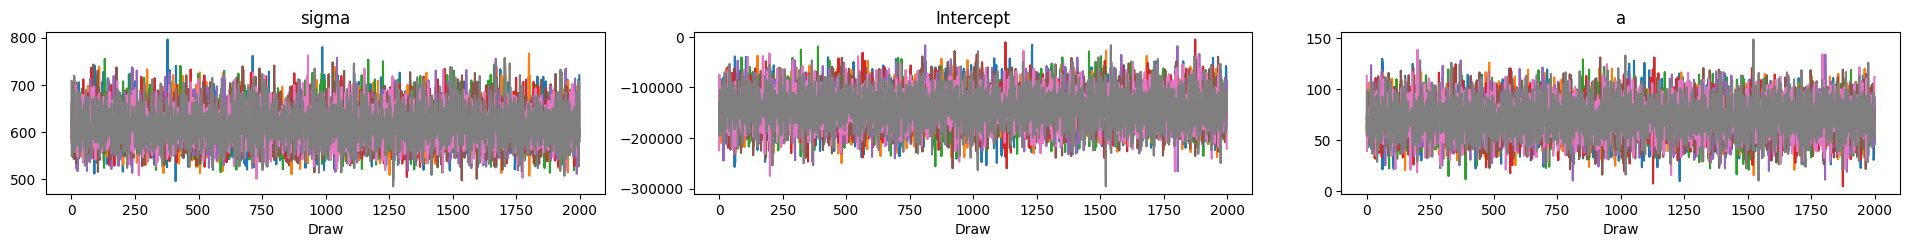

In [ ]:
model_B.plot_priors()
plt.tight_layout()
plt.show()
az.plot_trace(idata_B);
plt.tight_layout() #this spaces the plots out so that they don't overlap

model_D.plot_priors()
plt.tight_layout()
plt.show()
az.plot_trace(idata_D);
plt.tight_layout() #this spaces the plots out so that they don't overlap

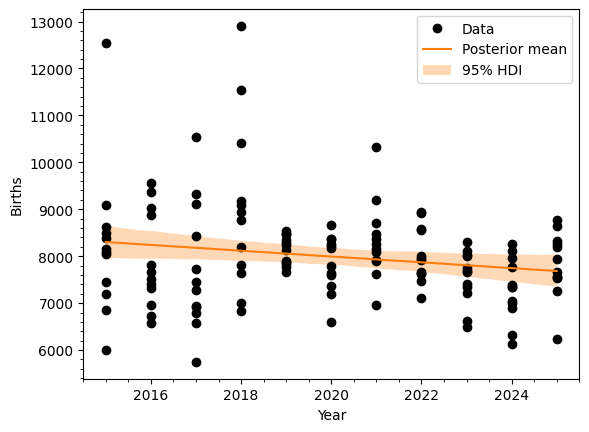

In [ ]:
x_rangeB = np.linspace(2015, 2025, 100) # Predict across a range of x values from 1 to 11
new_dataB = pd.DataFrame({"x": x_rangeB}) #dataframe with the new x-values
model_B.predict(idata_B, data=new_dataB, kind='response_params') #predict the distribution of regression lines at each x-value

# Get the xarray DataArray for 'mu'
y_mean_draws_xarray = idata_B.posterior["mu"]

# Compute posterior mean and HDI at each x point using the xarray DataArray
posterior_meanB = y_mean_draws_xarray.mean(dim=['chain', 'draw']).values
hdi = az.hdi(y_mean_draws_xarray, prob=0.95).values

# Plot the results
plt.plot(df['Year'], df['Births'], 'ok', label="Data")
plt.plot(x_rangeB, posterior_meanB, color="C1", label="Posterior mean")
plt.fill_between(
    x_rangeB,
    hdi[:, 0],
    hdi[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI",
    edgecolor = None
)
plt.xlabel('Year')
plt.ylabel('Births')
plt.legend()
plt.minorticks_on()